# Notebook 01 — Model Definition & Ideal Reference

**Goal**: Define the long-range Ising Hamiltonian, build Trotter circuits
assuming all-to-all connectivity (zero routing overhead), and compute exact
reference magnetisation values.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.model import (
    coupling_matrix, coupling_pairs,
    exact_trotter_magnetization,
)
from src.circuits import build_ideal_trotter_circuit, transpile_to_ideal
from src.metrics import extract_metrics, save_metrics

## Global parameters (shared across all notebooks)

In [2]:
N_QUBITS = 6
ALPHAS = [0.5, 1.0, 2.0, 4.0, 8.0]
CUTOFF_FRAC = 0.01  # keep pairs with J >= 1% of J_max
H_FIELD = 1.0
THETA = np.pi / 4
MAX_STEPS = 8
SEED = 42
GEOMETRY = "chain"

## 1. Coupling structure vs α

The cutoff makes α control the **number of active pairs** in the circuit:
small α → many long-range pairs, large α → nearest-neighbour only.

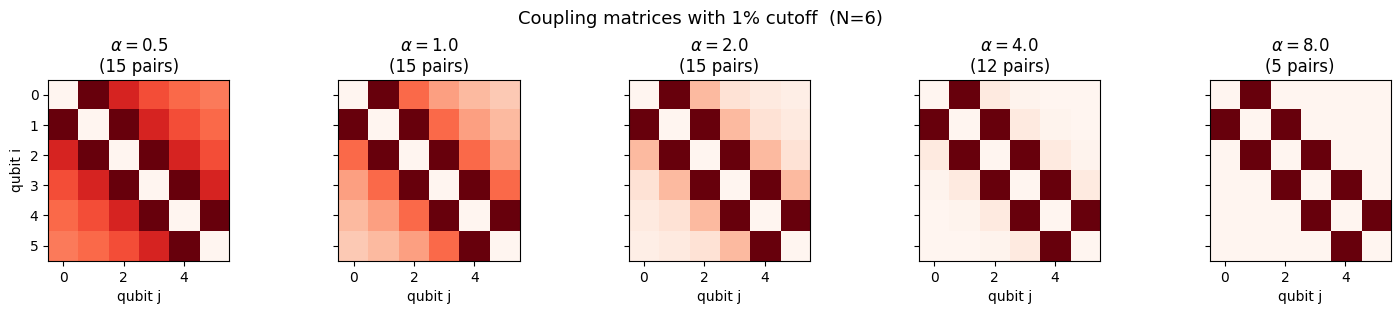

In [3]:
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(3 * len(ALPHAS), 3), sharey=True)
for ax, alpha in zip(axes, ALPHAS):
    J = coupling_matrix(N_QUBITS, alpha)
    J_full = J + J.T
    J_full[J_full < CUTOFF_FRAC * J.max()] = 0
    im = ax.imshow(J_full, cmap="Reds", vmin=0)
    n_pairs = len(coupling_pairs(N_QUBITS, alpha, cutoff_frac=CUTOFF_FRAC))
    ax.set_title(rf"$\alpha={alpha}$" + f"\n({n_pairs} pairs)")
    ax.set_xlabel("qubit j")
axes[0].set_ylabel("qubit i")
fig.suptitle(f"Coupling matrices with {CUTOFF_FRAC:.0%} cutoff  (N={N_QUBITS})", fontsize=13)
fig.tight_layout()
plt.savefig("../results/coupling_matrices.png", dpi=150, bbox_inches="tight")
#plt.show()

## 2. Build ideal circuits and extract metrics

In [4]:
from src.simulate import simulate_mz

all_metrics = []

for alpha in ALPHAS:
    for n_steps in range(MAX_STEPS + 1):
        circ = build_ideal_trotter_circuit(
            N_QUBITS, alpha, THETA, n_steps, measure=True, cutoff_frac=CUTOFF_FRAC, geometry=GEOMETRY
        )
        circ_t = transpile_to_ideal(circ, N_QUBITS, seed=SEED)
        m = extract_metrics(circ_t, "ideal", N_QUBITS, alpha, n_steps, THETA)
        m.mz_exact = exact_trotter_magnetization(
            N_QUBITS, alpha, H_FIELD, THETA, n_steps, cutoff_frac=CUTOFF_FRAC, geometry=GEOMETRY
        )
        m.mz_sim = simulate_mz(circ, N_QUBITS)
        all_metrics.append(m)

save_metrics(all_metrics, "../results/ideal_metrics.json")
print(f"Saved {len(all_metrics)} records")

# Print summary for step=1
print(f"\n{'alpha':>6}  {'pairs':>5}  {'2Q depth':>8}  {'2Q count':>8}  {'Mz':>8}")
print("-" * 42)
for m in all_metrics:
    if m.n_steps == 1:
        n_p = len(coupling_pairs(N_QUBITS, m.alpha, CUTOFF_FRAC))
        print(f"{m.alpha:>6.1f}  {n_p:>5}  {m.two_q_depth:>8}  "
              f"{m.two_q_count:>8}  {m.mz_exact:>8.4f}")

Saved 45 records

 alpha  pairs  2Q depth  2Q count        Mz
------------------------------------------
   0.5     15         5        15    0.7396
   1.0     15         5        15    0.6793
   2.0     15         5        15    0.5417
   4.0     12         5        12    0.4521
   8.0      5         2         5    0.4307


## 3. Exact magnetisation sweep

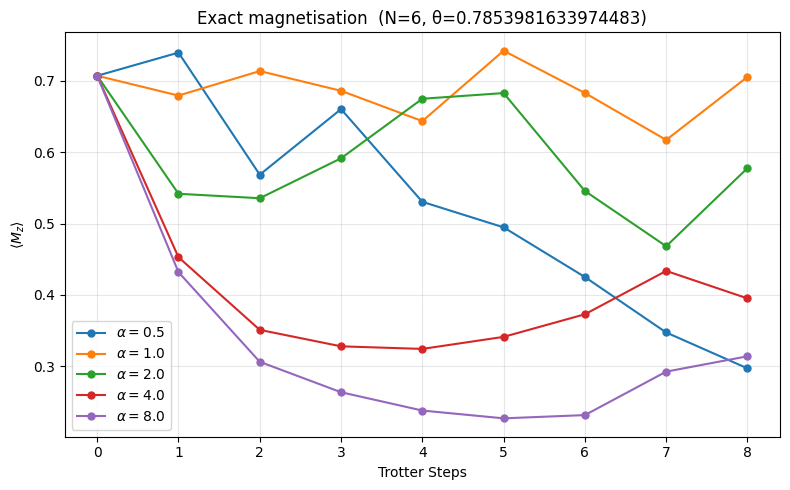

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
steps = np.arange(MAX_STEPS + 1)
for alpha in ALPHAS:
    mz = [exact_trotter_magnetization(N_QUBITS, alpha, H_FIELD, THETA, s, geometry=GEOMETRY)
          for s in steps]
    ax.plot(steps, mz, "o-", label=rf"$\alpha={alpha}$", markersize=5)
ax.set_xlabel("Trotter Steps")
ax.set_ylabel(r"$\langle M_z \rangle$")
ax.set_title(f"Exact magnetisation  (N={N_QUBITS}, θ={THETA})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("../results/exact_magnetisation.png", dpi=150)
#plt.show()